In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
if_renormalon = False

In [15]:
result_set = {}
accuracies = ["4params_fit_2","4params_scan_2"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("../result/"+XLL+".csv")

Import

In [16]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("      ", ",")
    corrected_string = corrected_string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set_1 = {}
Ω1_set = {}
a_set_2 = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set_1[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    if if_renormalon == False:
        for i in range(cols):
            a_list[i] = params[:,i]
    if if_renormalon == True:
        Ω1_array = params[:,0]
        Ω1_set[XLL] = Ω1_array
        for i in range(cols-1):
            a_list[i] = params[:,i+1]
            
    a_set_2[XLL] = pd.DataFrame(a_list)

    #print(a_list)

In [17]:
a_set_1 = {}
a_set = {}
αs_set = {}
for XLL in accuracies:
    a_list = {}
    a_set_1[XLL] = pd.DataFrame(a_set_2[XLL])
    df_αs = pd.DataFrame({"αs": αs_set_1[XLL]})
    df_total=pd.concat([df_αs,a_set_1[XLL]],axis=1)
    nonzero = df_total[(df_total != -1).all(axis=1)]
    print(len(nonzero))
    αs_set[XLL] = nonzero["αs"]
    for i in range(nonzero.shape[1]-1):
        a_list[i]= np.array(nonzero[i])
    a_set[XLL] = a_list

200
200


In [18]:
for XLL in accuracies:
    αs_array = αs_set[XLL]
    print(XLL)
    print(" A: med is",round(np.percentile(a_set[XLL][0],50),3), ", up is",round(np.percentile(a_set[XLL][0],84)-np.percentile(a_set[XLL][0],50),3),", down is",round(np.percentile(a_set[XLL][0],50)-np.percentile(a_set[XLL][0],16),3) )
    print(" a1: med is",round(np.percentile(a_set[XLL][1],50),3),", up is",round(np.percentile(a_set[XLL][1],84)-np.percentile(a_set[XLL][1],50),3),", down is",round(np.percentile(a_set[XLL][1],50)-np.percentile(a_set[XLL][1],16),3) )
    print(" a2: med is",round(np.percentile(a_set[XLL][2],50),3),", up is",round(np.percentile(a_set[XLL][2],84)-np.percentile(a_set[XLL][2],50),3),", down is",round(np.percentile(a_set[XLL][2],50)-np.percentile(a_set[XLL][2],16),3) )
    print(" B: med is",round(np.percentile(a_set[XLL][3],50),3),", up is",round(np.percentile(a_set[XLL][3],84)-np.percentile(a_set[XLL][3],50),3),", down is",round(np.percentile(a_set[XLL][3],50)-np.percentile(a_set[XLL][3],16),3) )
    print()

4params_fit_2
 A: med is 0.876 , up is 0.003 , down is 0.003
 a1: med is 2.712 , up is 0.032 , down is 0.036
 a2: med is 1.108 , up is 0.007 , down is 0.009
 B: med is 1.138 , up is 0.033 , down is 0.03

4params_scan_2
 A: med is 0.88 , up is 0.013 , down is 0.013
 a1: med is 2.705 , up is 0.103 , down is 0.142
 a2: med is 1.104 , up is 0.009 , down is 0.007
 B: med is 1.132 , up is 0.021 , down is 0.017



In [19]:
#medians = [0.886,2.67,1.087]
#medians = [0.835,2.778,1.191,1.372]
medians = [0.876,2.712,1.108,1.138]
for XLL in accuracies:
    αs_array = αs_set[XLL]
    print(XLL)
    print(" A: med is",round(medians[0],3), ", up is",round(np.percentile(a_set[XLL][0],84)-medians[0],3),", down is",round(medians[0]-np.percentile(a_set[XLL][0],16),3) )
    print(" a1: med is",round(np.percentile(medians[1],50),3),", up is",round(np.percentile(a_set[XLL][1],84)-np.percentile(medians[1],50),3),", down is",round(np.percentile(medians[1],50)-np.percentile(a_set[XLL][1],16),3) )
    print(" a2: med is",round(np.percentile(medians[2],50),3),", up is",round(np.percentile(a_set[XLL][2],84)-np.percentile(medians[2],50),3),", down is",round(np.percentile(medians[2],50)-np.percentile(a_set[XLL][2],16),3) )
    print(" B: med is",round(np.percentile(medians[3],50),3),", up is",round(np.percentile(a_set[XLL][3],84)-np.percentile(medians[3],50),3),", down is",round(np.percentile(medians[3],50)-np.percentile(a_set[XLL][3],16),3) )
    print()

4params_fit_2
 A: med is 0.876 , up is 0.003 , down is 0.003
 a1: med is 2.712 , up is 0.032 , down is 0.036
 a2: med is 1.108 , up is 0.007 , down is 0.009
 B: med is 1.138 , up is 0.033 , down is 0.03

4params_scan_2
 A: med is 0.876 , up is 0.017 , down is 0.009
 a1: med is 2.712 , up is 0.097 , down is 0.149
 a2: med is 1.108 , up is 0.005 , down is 0.011
 B: med is 1.138 , up is 0.015 , down is 0.024



Correlation

In [20]:
data = {}
mean = {}
df_set = {}
cov_matrix = {}
std_devs = {}
corr_matrix = {}

for XLL in accuracies:
    
    data[XLL]={}
    mean[XLL]={}

    a_list = a_set[XLL]

    l=len(a_list)
    for i in range(l):
        data[XLL][i] = a_list[i]
        mean[XLL][i] = np.mean(data[XLL][i])

    df_set[XLL]=pd.DataFrame(data[XLL])
    X = df_set[XLL].values

    cov_matrix[XLL] = np.cov(X, rowvar=False)
    std_devs[XLL] = np.sqrt(np.diag(cov_matrix[XLL]))
    corr_matrix[XLL] = cov_matrix[XLL] / np.outer(std_devs[XLL], std_devs[XLL])

for XLL in accuracies:
    display(XLL)
    display("mean:", mean[XLL])
    display("covariance matrix:", corr_matrix[XLL])
    display(df_set[XLL])

'4params_fit_2'

'mean:'

{0: 0.8755823, 1: 2.70938805, 2: 1.10703545, 3: 1.13768535}

'covariance matrix:'

array([[ 1.        , -0.47637026, -0.39233825, -0.65040921],
       [-0.47637026,  1.        ,  0.64249029,  0.16346958],
       [-0.39233825,  0.64249029,  1.        ,  0.61535787],
       [-0.65040921,  0.16346958,  0.61535787,  1.        ]])

...

'mean:'

{0: 0.8797974, 1: 2.6961795, 2: 1.10480745, 3: 1.1329535}

'covariance matrix:'

array([[ 1.        , -0.37557976, -0.5073188 , -0.77781387],
       [-0.37557976,  1.        , -0.1156958 ,  0.79951579],
       [-0.5073188 , -0.1156958 ,  1.        ,  0.43666568],
       [-0.77781387,  0.79951579,  0.43666568,  1.        ]])

,0,1,2,3
0,0.88911,2.74328,1.09057,1.11886
1,0.87062,2.80363,1.11412,1.16097
2,0.87443,2.82274,1.10647,1.15460
3,0.88216,2.73454,1.09370,1.12324
4,0.89173,2.63045,1.09319,1.10701
...,...,...,...,...
195,0.89567,2.73519,1.09892,1.12353
196,0.87486,2.81457,1.09959,1.14590
197,0.88357,2.79250,1.08883,1.12660
198,0.87327,2.78285,1.10587,1.14751


Plot

In [21]:
scale_68 = np.sqrt(2.279)
scale_95 = np.sqrt(5.991)

from matplotlib.patches import Ellipse
def draw_ellipse(mean, cov, scale, ax, **kwargs):

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = 2.0 * scale * np.sqrt(eigenvalues)
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    ell = Ellipse(xy=mean, width=eigenvalues[0], height=eigenvalues[1], angle=angle, **kwargs)
    
    ax.add_artist(ell)

In [22]:
data_set = {}

for XLL in accuracies:
    data_set[XLL] = df_set[XLL].copy()
    l = df_set[XLL].shape[0]
    XLL_series = pd.Series([XLL]*l)
    data_set[XLL]["XLL"] =  XLL_series

data_combined = pd.DataFrame()
df_c = pd.DataFrame()
for XLL in accuracies:
    data_combined = pd.concat([data_combined,data_set[XLL]],ignore_index=True)
    df_c = pd.concat([data_combined,df_set[XLL]],ignore_index=True)
#display(data_set['bbstar_fit_cut'][3])

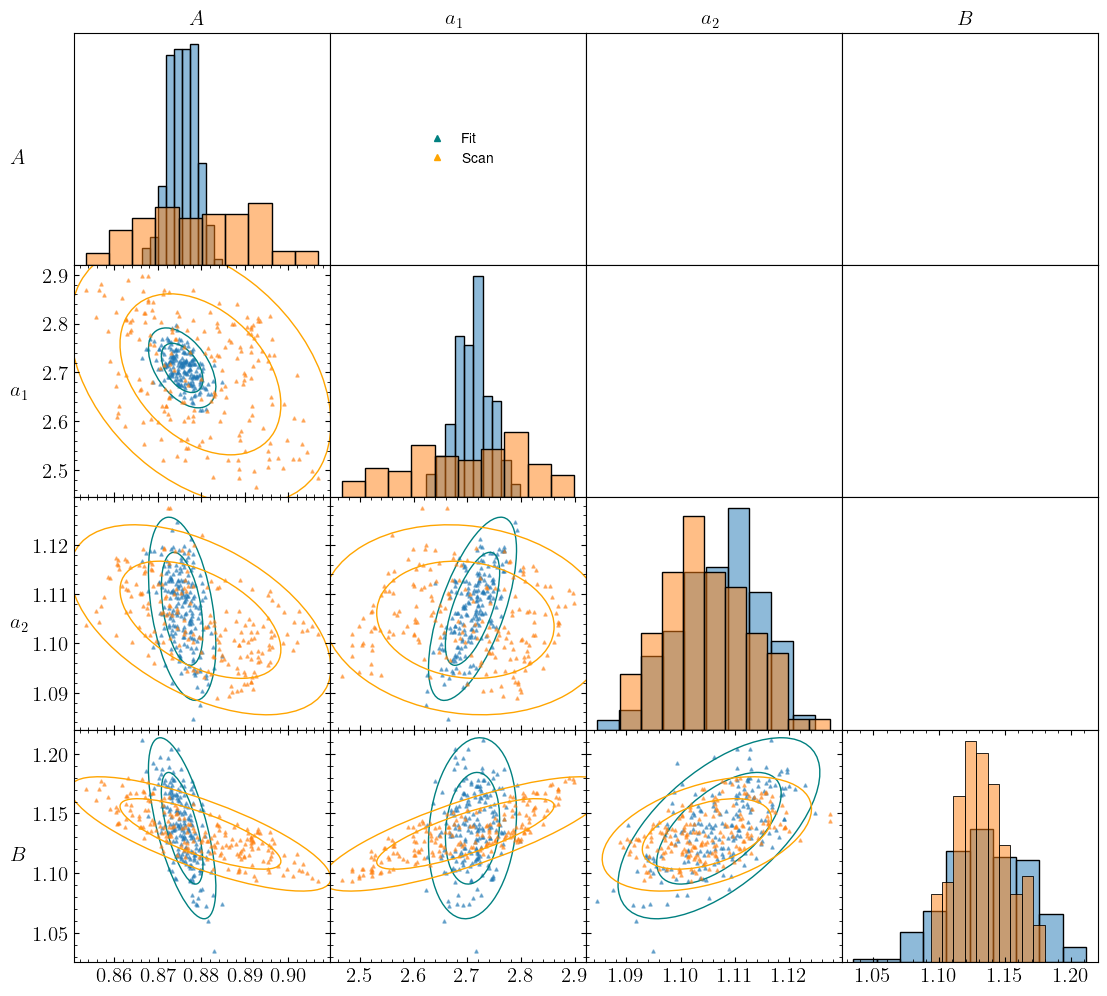

In [23]:
from scipy.stats import gaussian_kde
import seaborn as sns

fig, axes = plt.subplots(4, 4, figsize=(11, 10), sharex='col')
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12, ax13, ax14, ax15, ax16 = axes.ravel()

sizeOfFont= 15
sizeOfTick = 15
sizeOfPoint = 5
transOfPoint = 0.5
shapeOfPoint = "^"

color = ["teal","orange"]
labels = [0,1,2,3]

data_set = {}

k=0
for XLL in accuracies:
    #print(data[XLL])
    df = df_set[XLL].copy()

    for i in range(4):
        for j in range(0,i):  
            ax = axes[i, j]
            x=data[XLL][labels[j]]
            y=data[XLL][labels[i]]
            ax.scatter(x,y,s=sizeOfPoint, alpha=transOfPoint, marker=shapeOfPoint)
            mean = df.mean().values[[j, i]]
            cov = np.cov(df.values.T[[j, i]])
            draw_ellipse(mean, cov, scale_68, ax, edgecolor=color[k], fc='None')
            draw_ellipse(mean, cov, scale_95, ax, edgecolor=color[k], fc='None')

        ax = axes[i, i]
        x = data[XLL][labels[i]]
        #sns.kdeplot(x, ax=ax, fill=True, bw_adjust=1, legend=False)
        sns.histplot(x, ax=ax, bins=10, stat='density', fill=True, legend=False, alpha=0.5)
        ax.set_ylabel('')

    k=k+1

#-------------------------------------------------------------------------------------------------------------------------

#-------------------------------------------------------------------------------------------------------------------------

#-------------------------------------------------------------------------------------------------------------------------
for i in range(4):
    for j in range(0,i):
        ax = axes[i,j]
        ax.minorticks_on()
        ax.tick_params(direction='in', top=True, right=True, labelsize = sizeOfFont)
        ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
        ax.set_xlabel('')
        ax.set_ylabel('')

for i in range(4):
    for j in range(i,4):
        axes[i,j].set_yticks([])

for i in range(4):
    for j in range(1,4):
        axes[i,j].set_yticklabels([])

axes[3,3].minorticks_on()
axes[3,3].tick_params(direction='in', top=True, right=True, labelsize = sizeOfFont)
axes[3,3].tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)  
#-------------------------------------------------------------------------------------------------------------------------

names=[r"\rm $A$",r"\rm $a_1$",r"\rm $a_2$",r"\rm $B$"]
props = dict(boxstyle='round', facecolor='white', alpha=0)
i=0
for ax in axes[0, :]:
    ax.text(0.45, 1.1, names[i], transform=ax.transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
    i=i+1
j=0
for ax in axes[:, 0]:
    ax.text(-0.25, 0.5,  names[j], transform=ax.transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
    j=j+1

axes[0, 0].set_yticks([])


import matplotlib.lines as mlines
fit_cut_handle = mlines.Line2D([], [], color=color[0], marker=shapeOfPoint, linestyle='None', markersize=sizeOfPoint, label='Fit')
scan_handle = mlines.Line2D([], [], color=color[1], marker=shapeOfPoint, linestyle='None', markersize=sizeOfPoint, label='Scan')
axes[0, 1].legend(handles=[fit_cut_handle, scan_handle], loc='center', frameon=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)
plt.show()

fig.savefig('fit_1.pdf', bbox_inches='tight')